# Reproducible Performance Analysis

This notebook provides data processing and result visualization for the performance evaluation of lightweight convolutional neural networks trained on the Tiny ImageNet dataset. Experimental metrics are extracted from structured logs produced during controlled execution on a cluster environment.

The analyses enable quantitative comparison among selected architectures in terms of accuracy evolution, loss behavior, and system-level resource indicators collected during training.


## Data Loading

A set of structured CSV files contains the full record of metrics collected during each training execution.  
These files encode:

- Epoch-wise training and validation statistics
- Telemetry sampled from the execution environment
- Execution identifiers (architecture and random seed)

This stage locates and enumerates all available logs, preparing them for parsing and merging into a single analytical dataset.


In [59]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(".").resolve()
LOGS_DIR = PROJECT_DIR / "logs_csv"

print("Found logs directory:", LOGS_DIR.exists())

# CSVs das épocas (dados de treino)
epoch_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*.csv")
    if not f.name.endswith("_metadata.csv")
])

# CSVs de metadados (informações gerais de cada run)
metadata_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*_metadata.csv")
])

print("Epoch CSV count:", len(epoch_csv_files))
print("Metadata CSV count:", len(metadata_csv_files))

# mostrar alguns
epoch_csv_files[:5], metadata_csv_files[:5]

Found logs directory: True
Epoch CSV count: 20
Metadata CSV count: 20


([WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_201648.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_205133.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_211222.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_bs_384_20251101_213733.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/efficientnet_b0/efficientnet_b0_epochs_100_

## Merging Logs and Parsing Metadata

Each CSV file represents one execution with a specific CNN architecture and random seed.
Model name and seed identifier are encoded in the file path.  
These attributes are extracted and included as structured columns in the dataset.

The individual logs are then concatenated into a unified table to enable aggregated analysis
across architectures and repeated executions.


In [62]:
from pathlib import Path
import pandas as pd

LOGS_DIR = Path("logs_csv")

# Arquivos das epochs (sem metadata)
epoch_csv_files = sorted([f for f in LOGS_DIR.glob("**/*.csv")
                          if not f.name.endswith("_metadata.csv")])

# Arquivos metadata
metadata_csv_files = sorted([f for f in LOGS_DIR.glob("**/*_metadata.csv")])

# Indexar metadata por prefixo do nome
metadata_map = {
    f.name.replace("_metadata.csv", ""): f
    for f in metadata_csv_files
}

def load_log_with_metadata(epoch_path: Path) -> pd.DataFrame:
    prefix = epoch_path.name.replace(".csv", "")
    meta_path = metadata_map[prefix]

    # Carregar metadata (primeiras 2 linhas)
    meta = pd.read_csv(meta_path, nrows=2)

    model = meta.loc[0, "model_name"]
    seed  = int(meta.loc[0, "seed"])

    # Carregar dados de epoch
    df = pd.read_csv(epoch_path)

    df["model"] = model
    df["seed"] = seed
    df["log_file"] = epoch_path.name

    return df

logs_list = [load_log_with_metadata(p) for p in epoch_csv_files]
logs_df = pd.concat(logs_list, ignore_index=True)

logs_df.head()

,epoch,train_loss,lr,elapsed_time_seconds,cpu_usage_percent,ram_peak_bytes,disk_read_bytes,disk_write_bytes,vram_peak_bytes,gpu_power_watts_avg,...,gpu_mem_used_bytes_avg,gpu_mem_used_bytes_peak,gpu_vram_used_bytes,val_accuracy,val_precision,val_recall,val_f1,model,seed,log_file
0,1,4.8095,0.1,6.4676,5.1312,2.760595e+09,0.0,16674816.0,NaN,108.1205,...,1.918796e+10,1.918796e+10,1.918796e+10,0.0929,0.0952,0.0929,0.0713,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
1,2,4.3001,0.1,6.1770,5.1688,2.760595e+09,0.0,2555904.0,NaN,127.9190,...,1.992616e+10,1.992616e+10,1.992616e+10,0.1688,0.1687,0.1688,0.1389,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
2,3,4.0624,0.1,6.0217,5.2188,2.760595e+09,0.0,6397952.0,NaN,128.3130,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2148,0.2536,0.2148,0.1920,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
3,4,3.9119,0.1,6.2683,5.0875,2.760595e+09,0.0,4358144.0,NaN,124.2560,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2322,0.2742,0.2322,0.2151,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...
4,5,3.8015,0.1,6.2783,5.1063,2.760595e+09,0.0,10964992.0,NaN,127.6517,...,1.992616e+10,1.992616e+10,1.992616e+10,0.2661,0.3104,0.2661,0.2524,efficientnet_b0,42,efficientnet_b0_epochs_100_bs_384_20251101_201...


## Validation Metrics Overview

For each architecture, five independent executions were performed using different random seeds.  
This enables statistical confidence when comparing performance across models.

The validation accuracy and F1-score logs are inspected to confirm:
- presence of all epochs recorded
- correct association of samples to model and execution seed
- no missing values in essential fields

The following summary provides an initial verification of metric consistency.


In [73]:
# Inspect distinct models and seed counts
models = logs_df['model'].unique()
seed_counts = logs_df.groupby('model')['seed'].nunique()

print("Detected models:", models)
print("\nSeed count per model:")
print(seed_counts)

# Check for missing metrics (sanity validation)
missing = logs_df[['val_accuracy', 'val_f1']].isna().sum()
missing

epoch_counts = logs_df.groupby(["model", "seed"])["epoch"].nunique()
print(epoch_counts.unstack(0))

Detected models: ['efficientnet_b0' 'mobilenet_V1' 'shufflenet_v2' 'squeezenet']

Seed count per model:
model
efficientnet_b0    5
mobilenet_V1       5
shufflenet_v2      5
squeezenet         5
Name: seed, dtype: int64
model  efficientnet_b0  mobilenet_V1  shufflenet_v2  squeezenet
seed                                                           
42                 100           100            100         100
52                 100           100            100         100
62                 100           100            100         100
72                 100           100            100         100
82                 100           100            100         100


### Confidence Interval Aggregation

For each model and epoch, validation metrics from the five executions
(seeds) are aggregated. We compute:

- Mean validation accuracy
- 95% CI for validation accuracy
- Mean validation F1-score
- 95% CI for validation F1-score

These aggregated series will be used in the comparative plots that follow.


In [78]:
import numpy as np

# Compute mean and CI95 for accuracy + F1 per model & epoch
agg_df = (
    logs_df.groupby(['model', 'epoch'])
           .agg(
               val_acc_mean=('val_accuracy', 'mean'),
               val_acc_std=('val_accuracy', 'std'),
               val_f1_mean=('val_f1', 'mean'),
               val_f1_std=('val_f1', 'std'),
               n=('val_accuracy', 'count')
           )
           .reset_index()
)

# Confidence interval width = 1.96 * std / sqrt(n)
agg_df['val_acc_ci95'] = 1.96 * agg_df['val_acc_std'] / np.sqrt(agg_df['n'])
agg_df['val_f1_ci95'] = 1.96 * agg_df['val_f1_std'] / np.sqrt(agg_df['n'])

# Optional: handle n=1 (avoid NaN CI)
agg_df['val_acc_ci95'] = agg_df['val_acc_ci95'].fillna(0)
agg_df['val_f1_ci95'] = agg_df['val_f1_ci95'].fillna(0)

agg_df.head()

,model,epoch,val_acc_mean,val_acc_std,val_f1_mean,val_f1_std,n,val_acc_ci95,val_f1_ci95
0,efficientnet_b0,1,0.10176,0.005875,0.07548,0.002695,5,0.005150,0.002362
1,efficientnet_b0,2,0.16888,0.010582,0.14306,0.006919,5,0.009276,0.006065
2,efficientnet_b0,3,0.21866,0.008296,0.19554,0.007620,5,0.007272,0.006679
3,efficientnet_b0,4,0.24272,0.012006,0.22260,0.008637,5,0.010523,0.007571
4,efficientnet_b0,5,0.27182,0.008057,0.25246,0.007196,5,0.007062,0.006308


## Validation Curves with 95% Confidence Intervals

This section visualizes model performance throughout training.
For each epoch and architecture, the mean validation metric across
five independent runs is plotted as a solid line, while shaded
regions represent 95% confidence intervals. These bands indicate the
statistical reliability of the observed differences between models.


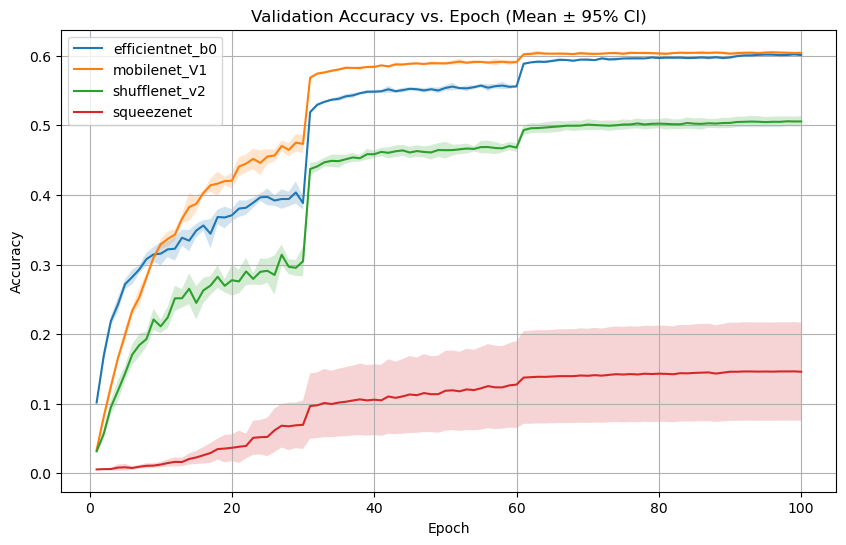

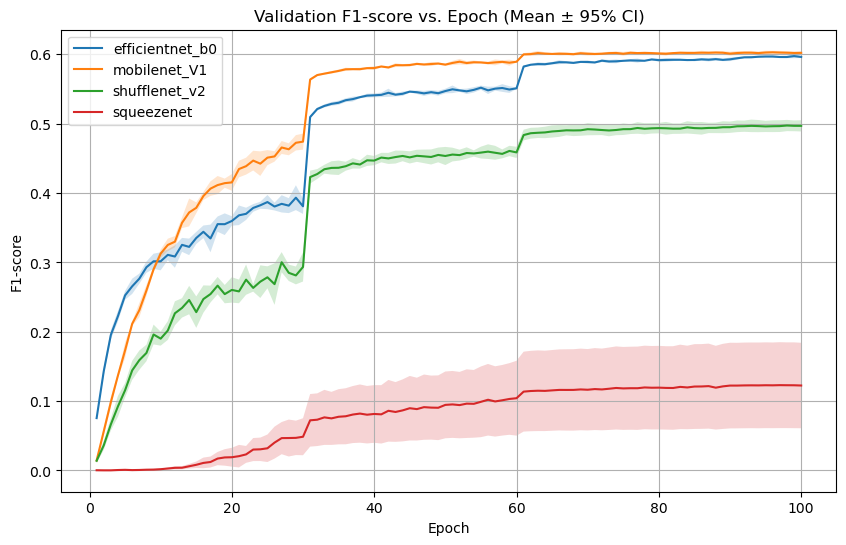

In [85]:
import matplotlib.pyplot as plt

# --- Plot Accuracy ---
plt.figure(figsize=(10, 6))
for model in agg_df['model'].unique():
    subset = agg_df[agg_df['model'] == model]
    plt.plot(subset['epoch'], subset['val_acc_mean'], label=model)
    plt.fill_between(
        subset['epoch'],
        subset['val_acc_mean'] - subset['val_acc_ci95'],
        subset['val_acc_mean'] + subset['val_acc_ci95'],
        alpha=0.2
    )

plt.title("Validation Accuracy vs. Epoch (Mean ± 95% CI)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot F1-score ---
plt.figure(figsize=(10, 6))
for model in agg_df['model'].unique():
    subset = agg_df[agg_df['model'] == model]
    plt.plot(subset['epoch'], subset['val_f1_mean'], label=model)
    plt.fill_between(
        subset['epoch'],
        subset['val_f1_mean'] - subset['val_f1_ci95'],
        subset['val_f1_mean'] + subset['val_f1_ci95'],
        alpha=0.2
    )

plt.title("Validation F1-score vs. Epoch (Mean ± 95% CI)")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

## Best Epoch Performance

To compare models fairly, we extract:

the best accuracy achieved in any epoch,

the best F1-score,

and the corresponding epoch.

This is done separately for each seed, allowing us to:

measure variability across executions,

compute mean ± 95% CI of the best values per model.

This step summarizes the actual achievable performance of each architecture, independent of the training dynamics.

In [88]:
import numpy as np

best_df = (
    logs_df.groupby(["model", "seed"])
    .agg(
        best_acc=("val_accuracy", "max"),
        best_f1=("val_f1", "max"),
    )
    .reset_index()
)

summary = (
    best_df.groupby("model")
    .agg(
        acc_mean=("best_acc", "mean"),
        acc_std=("best_acc", "std"),
        f1_mean=("best_f1", "mean"),
        f1_std=("best_f1", "std"),
        n=("best_acc", "count"),
    )
    .reset_index()
)

summary["acc_ci95"] = 1.96 * summary["acc_std"] / np.sqrt(summary["n"])
summary["f1_ci95"]  = 1.96 * summary["f1_std"]  / np.sqrt(summary["n"])

summary

,model,acc_mean,acc_std,f1_mean,f1_std,n,acc_ci95,f1_ci95
0,efficientnet_b0,0.60270,0.002299,0.59822,0.002459,5,0.002015,0.002155
1,mobilenet_V1,0.60586,0.002523,0.60400,0.002425,5,0.002212,0.002125
2,shufflenet_v2,0.50640,0.008608,0.49800,0.009666,5,0.007545,0.008473
3,squeezenet,0.14710,0.080611,0.12334,0.070779,5,0.070658,0.062041


## GPU Resource Metrics (Mean Across Runs)

Hardware-level metrics such as GPU utilization, memory usage and temperature
are inherently noisy even under identical configurations, due to effects such as
kernel scheduling, cooling control loops and driver-level activity. For these
signals, confidence intervals become visually dominant without adding much
interpretive value. 

To focus on deployment-relevant behavior, we report the **mean value across
the five executions** for each model and epoch, comparing the evolution of:
- average GPU utilization,
- average GPU memory usage (VRAM),
- average GPU temperature.



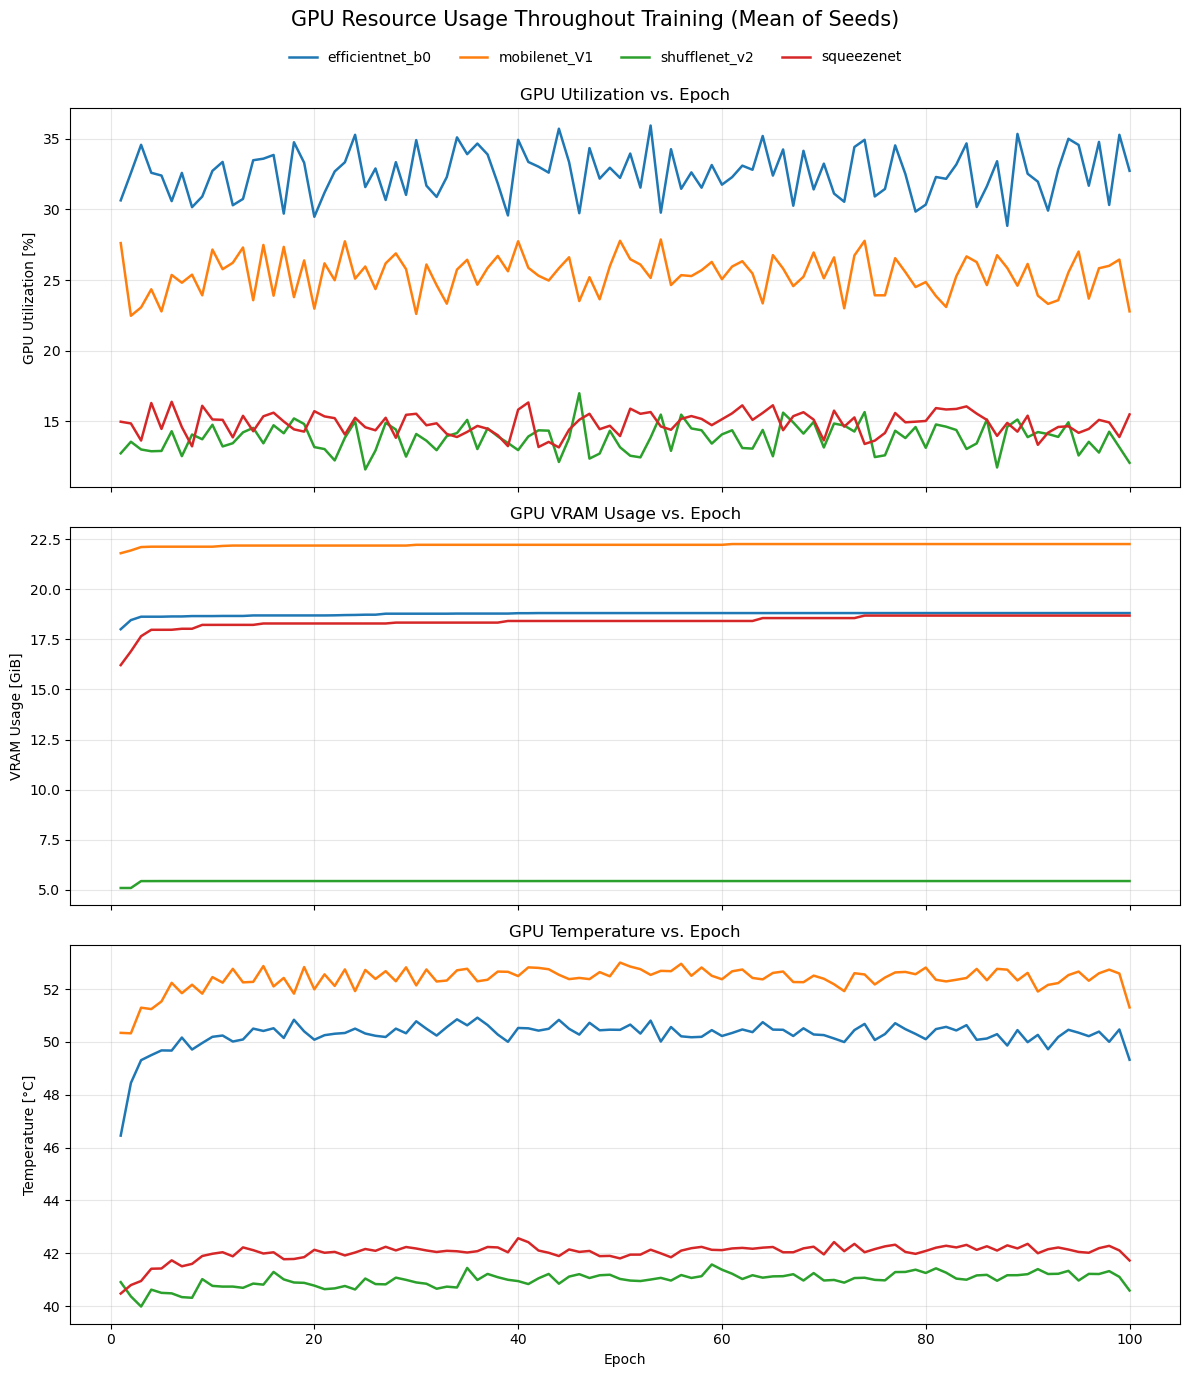

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Aggregation (mean per model & epoch)
# ============================

eff_df = (
    logs_df.groupby(["model", "epoch"])
    .agg(
        gpu_util_mean=("gpu_util_percent_avg", "mean"),
        gpu_vram_mean=("gpu_vram_used_bytes", "mean"),
        gpu_temp_mean=("gpu_temp_celsius_avg", "mean"),
    )
    .reset_index()
)

gpu_models = eff_df["model"].unique()

# ============================
# Plotting
# ============================

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

metric_plots = [
    ("gpu_util_mean", "GPU Utilization [%]", "GPU Utilization vs. Epoch"),
    ("gpu_vram_mean", "VRAM Usage [GiB]", "GPU VRAM Usage vs. Epoch"),
    ("gpu_temp_mean", "Temperature [°C]", "GPU Temperature vs. Epoch"),
]

for ax, (metric, ylabel, title) in zip(axes, metric_plots):
    for model in gpu_models:
        subset = eff_df[eff_df["model"] == model]

        y = subset[metric]

        if metric == "gpu_vram_mean":
            y = y / (1024**3)

        ax.plot(subset["epoch"], y, label=model, linewidth=1.8)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Epoch")

fig.suptitle(
    "GPU Resource Usage Throughout Training (Mean of Seeds)",
    fontsize=15,
)
fig.legend(
    gpu_models,
    loc="upper center",
    ncol=len(gpu_models),
    frameon=False,
    bbox_to_anchor=(0.5, 0.96),
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Training Time Analysis

This section evaluates the computational cost of each CNN architecture by analyzing training time.  
Since our logs contain per-epoch timing (`elapsed_time_seconds`), the total training time for each run is obtained by summing the epoch durations for each `(model, seed)` pair.

This analysis provides insights into:

- how fast each architecture trains,
- the variability of training time across different random seeds,
- the trade-off between training cost and model performance.

The plots below summarize the distribution of total training time and the per-epoch timing behavior for each model.
ity.

,model,seed,training_time_total
0,efficientnet_b0,42,616.1687
1,efficientnet_b0,52,320.1176
2,efficientnet_b0,62,354.8267
3,efficientnet_b0,72,610.3748
4,efficientnet_b0,82,617.5128
5,mobilenet_V1,42,318.6797
6,mobilenet_V1,52,448.5799
7,mobilenet_V1,62,328.9323
8,mobilenet_V1,72,690.3112
9,mobilenet_V1,82,423.6432


,mean,std,min,max,median
model,,,,,
efficientnet_b0,503.80012,152.354670,320.1176,617.5128,610.3748
mobilenet_V1,442.02926,150.025761,318.6797,690.3112,423.6432
shufflenet_v2,463.00840,179.848944,258.1596,607.9704,578.7641
squeezenet,657.47384,222.984850,389.6418,822.8488,817.1119


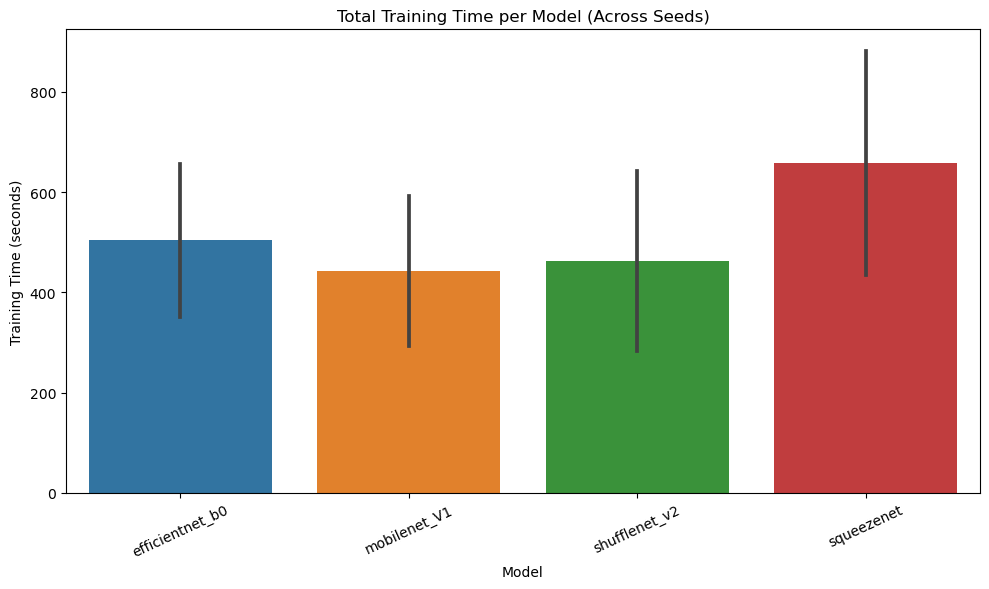

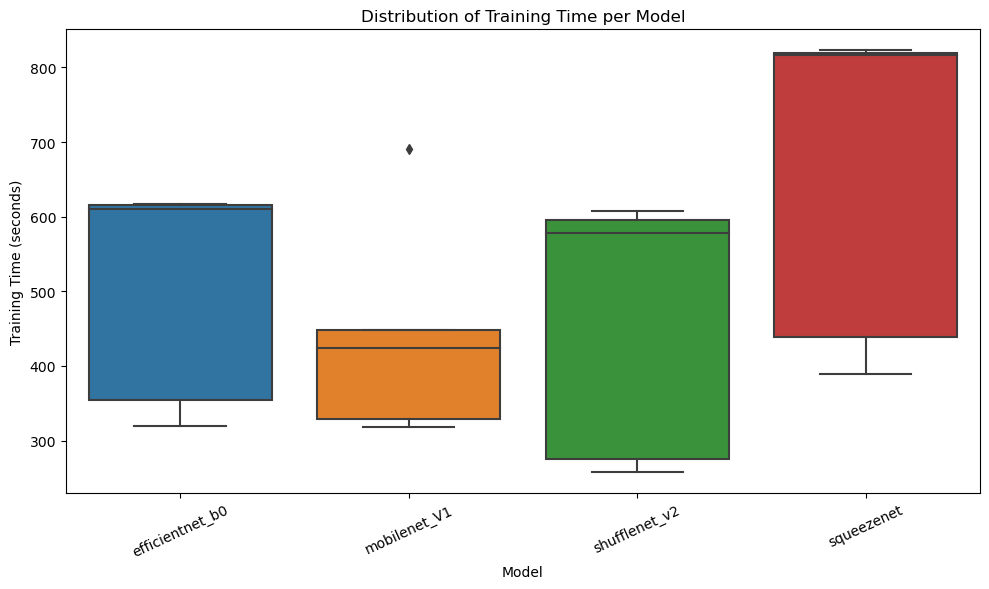

C:\Users\arthu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\arthu\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


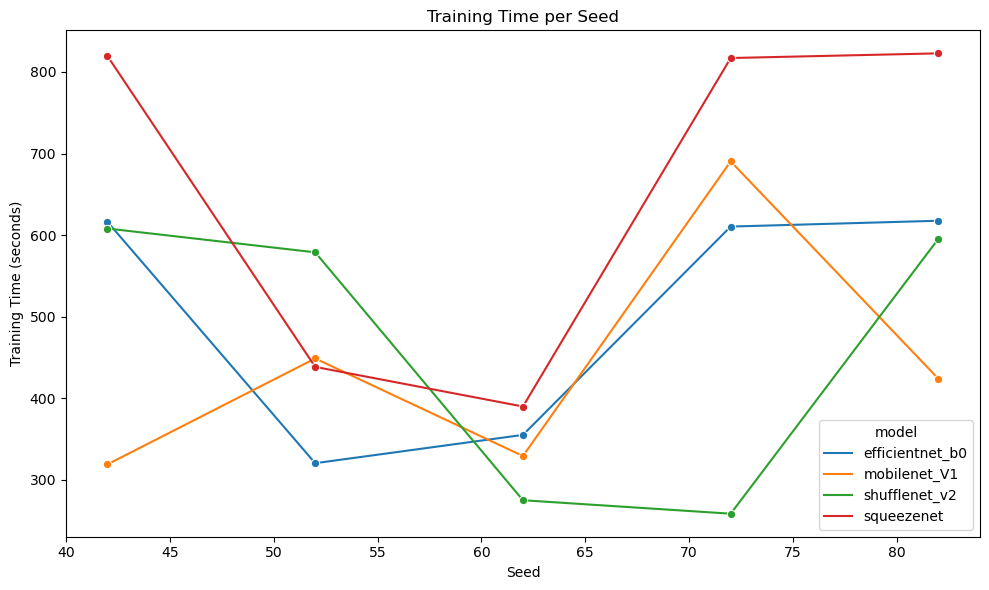

model
efficientnet_b0    5.038001
mobilenet_V1       4.420293
shufflenet_v2      4.630084
squeezenet         6.574738
Name: elapsed_time_seconds, dtype: float64

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the field exists
assert "elapsed_time_seconds" in logs_df.columns, "elapsed_time_seconds column not found."

# --- Compute total training time per (model, seed) run ---
run_times = (
    logs_df.groupby(["model", "seed"])["elapsed_time_seconds"]
           .sum()
           .reset_index()
           .rename(columns={"elapsed_time_seconds": "training_time_total"})
)

display(run_times)

# --- Summary statistics per model ---
training_stats = run_times.groupby("model")["training_time_total"].agg(
    ["mean", "std", "min", "max", "median"]
)

display(training_stats)

# =============================
# --- Visualization Section ---
# =============================

# --- Barplot: mean total training time per model ---
plt.figure(figsize=(10,6))
sns.barplot(data=run_times, x="model", y="training_time_total", errorbar="sd")
plt.title("Total Training Time per Model (Across Seeds)")
plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# --- Boxplot: distribution ---
plt.figure(figsize=(10,6))
sns.boxplot(data=run_times, x="model", y="training_time_total")
plt.title("Distribution of Training Time per Model")
plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# --- Lineplot: stability across seeds ---
plt.figure(figsize=(10,6))
sns.lineplot(data=run_times, x="seed", y="training_time_total", hue="model", marker="o")
plt.title("Training Time per Seed")
plt.ylabel("Training Time (seconds)")
plt.xlabel("Seed")
plt.tight_layout()
plt.show()

epoch_time_stats = logs_df.groupby("model")["elapsed_time_seconds"].mean()
display(epoch_time_stats)


## Accuracy vs Cost Tradeoff

This section evaluates the relationship between training cost and predictive performance for each CNN architecture.  
For every model, we compute:

- the mean validation accuracy across all five executions;
- the mean total training time (sum of per-epoch durations for each run).

Plotting these two quantities provides a clear view of the tradeoff between
**model efficiency** (training time) and **model performance** (accuracy).

Models located in the upper-left region of the plot are preferable, as they deliver
higher accuracy with lower computational cost.

,model,mean_val_accuracy,mean_training_time
0,efficientnet_b0,0.60270,503.80012
1,mobilenet_V1,0.60586,442.02926
2,shufflenet_v2,0.50640,463.00840
3,squeezenet,0.14710,657.47384


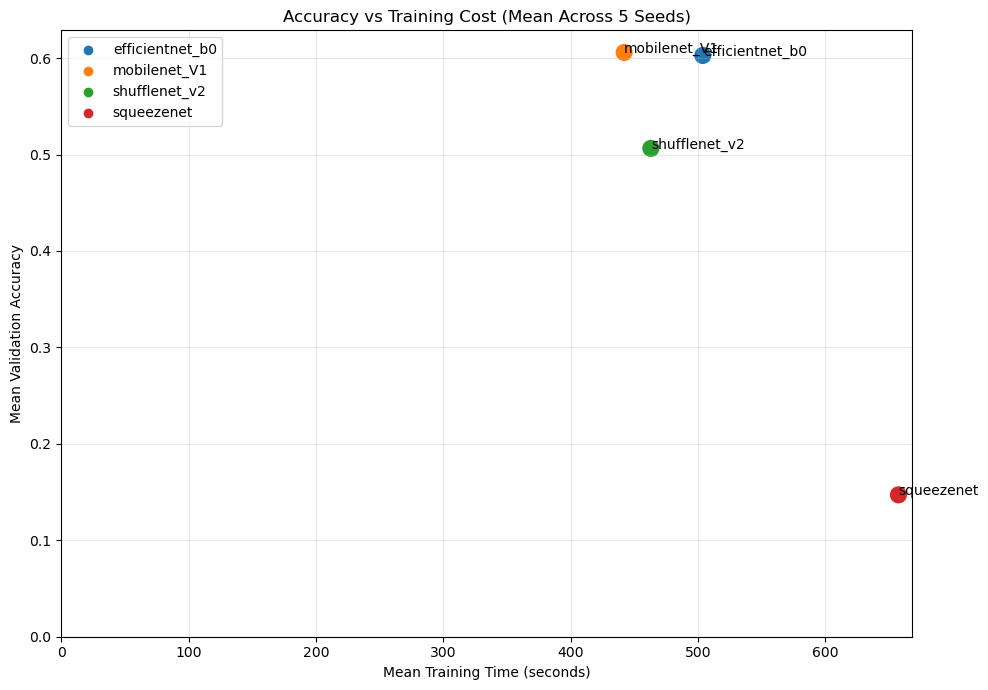

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

acc_per_seed = (
    logs_df.groupby(["model", "seed"])["val_accuracy"]
           .max()  # final epoch accuracy
           .reset_index()
)

acc_mean = (
    acc_per_seed.groupby("model")["val_accuracy"]
                .mean()
                .reset_index()
                .rename(columns={"val_accuracy": "mean_val_accuracy"})
)

cost_mean = (
    run_times.groupby("model")["training_time_total"]
             .mean()
             .reset_index()
             .rename(columns={"training_time_total": "mean_training_time"})
)

tradeoff_df = pd.merge(acc_mean, cost_mean, on="model")
display(tradeoff_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tradeoff_df,
    x="mean_training_time",
    y="mean_val_accuracy",
    hue="model",
    s=180,
    palette="tab10"
)

for _, row in tradeoff_df.iterrows():
    plt.text(
        row["mean_training_time"],
        row["mean_val_accuracy"],
        row["model"],
        fontsize=10
    )

plt.title("Accuracy vs Training Cost (Mean Across 5 Seeds)")
plt.xlabel("Mean Training Time (seconds)")
plt.ylabel("Mean Validation Accuracy")
plt.grid(alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()